In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 456kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]


In [4]:
T = 1000

beta = torch.linspace(
    1e-4,
    0.02,
    T
).to(device)

alpha = 1.0 - beta

alpha_hat = torch.cumprod(
    alpha,
    dim=0
)

In [5]:
print(beta.shape)
print(alpha_hat.shape)

torch.Size([1000])
torch.Size([1000])


In [6]:
# forward diffusion function

def add_noise(x0, t):

    sqrt_alpha_hat = torch.sqrt(alpha_hat[t])[:, None, None, None]

    sqrt_one_minus_alpha_hat = torch.sqrt(
        1 - alpha_hat[t]
    )[:, None, None, None]

    noise = torch.randn_like(x0)

    xt = (
        sqrt_alpha_hat * x0
        + sqrt_one_minus_alpha_hat * noise
    )

    return xt, noise

In [7]:
# test on one image

image, _ = dataset[0]

print(image.shape)

torch.Size([1, 28, 28])


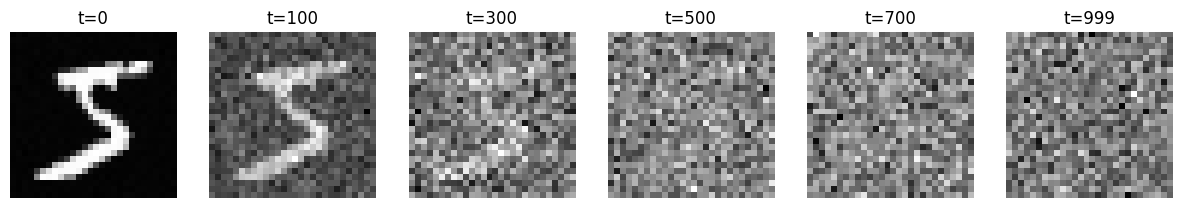

In [8]:
# visualize noise progression

image = image.unsqueeze(0).to(device)

timesteps = [0, 100, 300, 500, 700, 999]

plt.figure(figsize=(15,3))

for i, t in enumerate(timesteps):

    t_tensor = torch.tensor([t]).to(device)

    noisy_image, _ = add_noise(
        image,
        t_tensor
    )

    plt.subplot(1, len(timesteps), i+1)

    plt.imshow(
        noisy_image[0,0].cpu(),
        cmap="gray"
    )

    plt.title(f"t={t}")
    plt.axis("off")

plt.show()

A few observations:

At t=0, the digit is almost untouched.

Around t=100–300, the global structure of the digit is still visible.

Around t=500, the model would already find recognition difficult.

By t=999, it looks like pure Gaussian noise.

This confirms our implementation of the forward process is correct.

What you've implemented so far is essentially Equation (4) from the DDPM paper—the closed-form noising process.

In [9]:
import torch
import torch.nn as nn
import math

In [10]:
class TimeAwareCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 64)
        )

        self.conv1 = nn.Conv2d(
            1,
            64,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            64,
            64,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            64,
            1,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

    def forward(self, x, t):

        t_emb = sinusoidal_embedding(
            t,
            dim=32
        )

        t_emb = self.time_mlp(t_emb)

        t_emb = t_emb[:, :, None, None]

        h = self.conv1(x)

        h = h + t_emb

        h = self.relu(h)

        h = self.conv2(h)

        h = self.relu(h)

        out = self.conv3(h)

        return out

In [11]:
model = TimeAwareCNN().to(device)

Now we've verified:

✅ Forward diffusion works

✅ Noise scheduler works

✅ Network input/output dimensions work

At this point we can perform the first actual DDPM training step.

Next steps :

Generate Training Data

Remember what the paper does during training:

Take a clean image x
0
	​

Sample a random timestep t

Generate noise ϵ

Create x
t
	​

Give (x
t
	​
,t) to the network

Network predicts noise

Compute MSE loss between predicted and actual noise

In [12]:
import math

In [13]:
def sinusoidal_embedding(timesteps, dim=32):

    device = timesteps.device

    half_dim = dim // 2

    embeddings = math.log(10000) / (half_dim - 1)

    embeddings = torch.exp(
        torch.arange(
            half_dim,
            device=device
        ) * -embeddings
    )

    embeddings = timesteps[:, None] * embeddings[None, :]

    embeddings = torch.cat(
        (
            torch.sin(embeddings),
            torch.cos(embeddings)
        ),
        dim=1
    )

    return embeddings

In [14]:
t = torch.tensor([0, 100, 500]).to(device)

emb = sinusoidal_embedding(t)

print(emb.shape)

torch.Size([3, 32])


In [15]:
print(emb[0][:8])
print(emb[1][:8])
print(emb[2][:8])

tensor([0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
tensor([-0.5064, -0.6517, -0.8480, -0.1405,  0.7498, -0.9975,  0.5889,  0.9777],
       device='cuda:0')
tensor([-0.4678,  0.3966,  0.9400, -0.6479, -0.8901, -0.9380, -0.0069,  0.4913],
       device='cuda:0')


In [16]:
print(type(model))

<class '__main__.TimeAwareCNN'>


In [17]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

epochs = 5

for epoch in range(epochs):

    running_loss = 0

    for images, _ in loader:

        images = images.to(device)

        t = torch.randint(
            0,
            T,
            (images.shape[0],),
            device=device
        )

        xt, noise = add_noise(
            images,
            t
        )

        pred_noise = model(
            xt,
            t
        )

        loss = criterion(
            pred_noise,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)

    print(
        f"Epoch {epoch+1}: Loss = {avg_loss:.4f}"
    )

Epoch 1: Loss = 0.0707
Epoch 2: Loss = 0.0403
Epoch 3: Loss = 0.0372
Epoch 4: Loss = 0.0356
Epoch 5: Loss = 0.0346


Now we are building the actual U-Net.

In [18]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU()
        )

    def forward(self, x):

        return self.block(x)

In [19]:
class TinyUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Time embedding

        self.time_mlp = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 128)
        )

        # Encoder

        self.enc1 = DoubleConv(1, 64)

        self.pool = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)

        # Bottleneck

        self.bottleneck = DoubleConv(
            128,
            128
        )

        # Decoder

        self.up = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64 + 64,
            64
        )

        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x, t):

        t_emb = sinusoidal_embedding(
            t,
            dim=32
        )

        t_emb = self.time_mlp(t_emb)

        t_emb = t_emb[:, :, None, None]

        # Encoder

        x1 = self.enc1(x)

        x2 = self.pool(x1)

        x2 = self.enc2(x2)

        # Inject timestep

        x2 = x2 + t_emb

        # Bottleneck

        x3 = self.bottleneck(x2)

        # Decoder

        x4 = self.up(x3)

        x4 = torch.cat(
            [x4, x1],
            dim=1
        )

        x4 = self.dec1(x4)

        return self.final(x4)

In [20]:
model = TinyUNet().to(device)

In [21]:
xt = torch.randn(
    8,
    1,
    28,
    28
).to(device)

t = torch.randint(
    0,
    T,
    (8,),
    device=device
)

out = model(
    xt,
    t
)

print(out.shape)

torch.Size([8, 1, 28, 28])


In [22]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=out_channels
            ),

            nn.SiLU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=out_channels
            ),

            nn.SiLU()
        )

    def forward(self, x):

        return self.block(x)

In [23]:
model = TinyUNet().to(device)

In [24]:
out = model(xt, t)
print(out.shape)

torch.Size([8, 1, 28, 28])


If an interviewer asks:

"What DDPM-specific architectural choices did you implement?"

you'll be able to say:

"I used sinusoidal timestep embeddings, a U-Net backbone with skip connections, GroupNorm, and SiLU activations, following the design principles used in DDPM-style diffusion models."

That's already sounding much stronger than:

"I trained a CNN on MNIST."

In [25]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

epochs = 5

for epoch in range(epochs):

    running_loss = 0

    for images, _ in loader:

        images = images.to(device)

        t = torch.randint(
            0,
            T,
            (images.shape[0],),
            device=device
        )

        xt, noise = add_noise(
            images,
            t
        )

        pred_noise = model(
            xt,
            t
        )

        loss = criterion(
            pred_noise,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)

    print(
        f"Epoch {epoch+1}: Loss = {avg_loss:.4f}"
    )


Epoch 1: Loss = 0.0467
Epoch 2: Loss = 0.0307
Epoch 3: Loss = 0.0284
Epoch 4: Loss = 0.0271
Epoch 5: Loss = 0.0262


At this stage you've successfully implemented:

Forward diffusion

Noise schedule

DDPM training objective

Sinusoidal time embeddings

U-Net backbone

GroupNorm + SiLU

End-to-end training

This is already enough to say:

"Implemented and trained a DDPM-style diffusion model from scratch in PyTorch."

Next part : reverse diffusion

In [26]:
@torch.no_grad()
def sample(model, n_samples=16):

    model.eval()

    x = torch.randn(
        n_samples,
        1,
        28,
        28
    ).to(device)

    for t in reversed(range(T)):

        t_tensor = torch.full(
            (n_samples,),
            t,
            device=device,
            dtype=torch.long
        )

        predicted_noise = model(
            x,
            t_tensor
        )

        alpha_t = alpha[t]
        alpha_hat_t = alpha_hat[t]
        beta_t = beta[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha_t)
        ) * (
            x
            - (
                (1 - alpha_t)
                / torch.sqrt(1 - alpha_hat_t)
            )
            * predicted_noise
        ) + torch.sqrt(beta_t) * noise

    return x

In [27]:
samples = sample(
    model,
    n_samples=16
)

samples = samples.cpu()

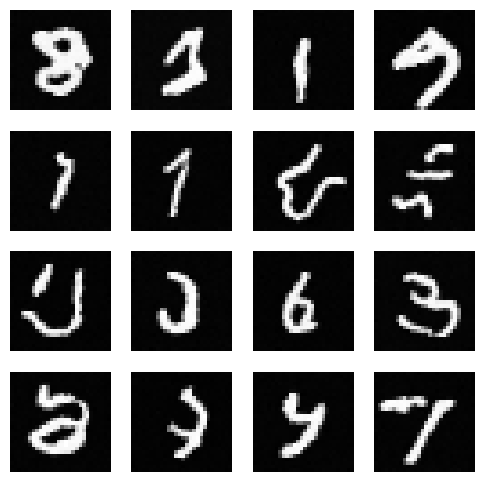

In [28]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(6,6)
)

for i, ax in enumerate(axes.flatten()):

    img = samples[i,0]

    ax.imshow(
        img,
        cmap="gray"
    )

    ax.axis("off")

plt.show()

In [29]:
# residual block
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.act = nn.SiLU()

        if in_channels != out_channels:

            self.shortcut = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.shortcut = nn.Identity()

    def forward(self, x):

        residual = self.shortcut(x)

        x = self.conv1(x)
        x = self.norm1(x)
        x = self.act(x)

        x = self.conv2(x)
        x = self.norm2(x)

        x = x + residual

        x = self.act(x)

        return x

In [30]:
block = ResidualBlock(
    64,
    64
).to(device)

x = torch.randn(
    8,
    64,
    28,
    28
).to(device)

print(block(x).shape)

torch.Size([8, 64, 28, 28])


In [31]:
# residual unet
class ResidualUNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.Linear(32, 128),
            nn.SiLU(),
            nn.Linear(128, 128)
        )

        # Encoder

        self.enc1 = ResidualBlock(
            1,
            64
        )

        self.pool = nn.MaxPool2d(2)

        self.enc2 = ResidualBlock(
            64,
            128
        )

        # Bottleneck

        self.bottleneck = ResidualBlock(
            128,
            128
        )

        # Decoder

        self.up = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = ResidualBlock(
            128,
            64
        )

        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x, t):

        t_emb = sinusoidal_embedding(
            t,
            dim=32
        )

        t_emb = self.time_mlp(t_emb)

        t_emb = t_emb[:, :, None, None]

        # Encoder

        x1 = self.enc1(x)

        x2 = self.pool(x1)

        x2 = self.enc2(x2)

        # Time injection

        x2 = x2 + t_emb

        # Bottleneck

        x3 = self.bottleneck(x2)

        # Decoder

        x4 = self.up(x3)

        x4 = torch.cat(
            [x4, x1],
            dim=1
        )

        x4 = self.dec1(x4)

        return self.final(x4)

In [32]:
model = ResidualUNet().to(device)

In [33]:
xt = torch.randn(
    8,
    1,
    28,
    28
).to(device)

t = torch.randint(
    0,
    T,
    (8,),
    device=device
)

out = model(
    xt,
    t
)

print(out.shape)

torch.Size([8, 1, 28, 28])


checking if the residual u-net improved something or not

In [34]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

epochs = 5

for epoch in range(epochs):

    running_loss = 0

    for images, _ in loader:

        images = images.to(device)

        t = torch.randint(
            0,
            T,
            (images.shape[0],),
            device=device
        )

        xt, noise = add_noise(
            images,
            t
        )

        pred_noise = model(
            xt,
            t
        )

        loss = criterion(
            pred_noise,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)

    print(
        f"Epoch {epoch+1}: Loss = {avg_loss:.4f}"
    )

Epoch 1: Loss = 0.0477
Epoch 2: Loss = 0.0304
Epoch 3: Loss = 0.0279
Epoch 4: Loss = 0.0270
Epoch 5: Loss = 0.0261


In [35]:
samples = sample(
    model,
    n_samples=16
)

samples = samples.cpu()

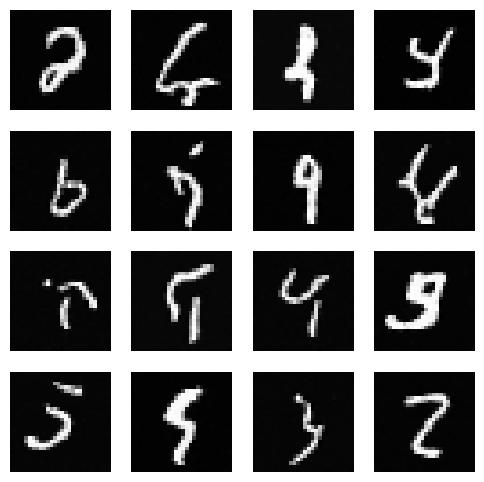

In [36]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(6,6)
)

for i, ax in enumerate(axes.flatten()):

    img = samples[i,0]

    ax.imshow(
        img,
        cmap="gray"
    )

    ax.axis("off")

plt.show()

In [37]:
class TimeResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, time_dim=128):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.time_proj = nn.Linear(
            time_dim,
            out_channels
        )

        self.act = nn.SiLU()

        if in_channels != out_channels:

            self.shortcut = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.shortcut = nn.Identity()

    def forward(self, x, t_emb):

        residual = self.shortcut(x)

        x = self.conv1(x)

        x = self.norm1(x)

        time = self.time_proj(t_emb)

        time = time[:, :, None, None]

        x = x + time

        x = self.act(x)

        x = self.conv2(x)

        x = self.norm2(x)

        x = x + residual

        x = self.act(x)

        return x

In [38]:
block = TimeResidualBlock(
    64,
    64
).to(device)

x = torch.randn(
    8,
    64,
    28,
    28
).to(device)

t_emb = torch.randn(
    8,
    128
).to(device)

out = block(
    x,
    t_emb
)

print(out.shape)

torch.Size([8, 64, 28, 28])


In [39]:
class FinalUNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.Linear(32, 128),
            nn.SiLU(),
            nn.Linear(128, 128)
        )

        # Encoder

        self.enc1 = TimeResidualBlock(
            1,
            64
        )

        self.pool = nn.MaxPool2d(2)

        self.enc2 = TimeResidualBlock(
            64,
            128
        )

        # Bottleneck

        self.bottleneck = TimeResidualBlock(
            128,
            128
        )

        # Decoder

        self.up = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = TimeResidualBlock(
            128,
            64
        )

        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x, t):

        t_emb = sinusoidal_embedding(
            t,
            dim=32
        )

        t_emb = self.time_mlp(t_emb)

        # Encoder

        x1 = self.enc1(
            x,
            t_emb
        )

        x2 = self.pool(x1)

        x2 = self.enc2(
            x2,
            t_emb
        )

        # Bottleneck

        x3 = self.bottleneck(
            x2,
            t_emb
        )

        # Decoder

        x4 = self.up(x3)

        x4 = torch.cat(
            [x4, x1],
            dim=1
        )

        x4 = self.dec1(
            x4,
            t_emb
        )

        return self.final(x4)

In [40]:
model = FinalUNet().to(device)

In [41]:
xt = torch.randn(
    8,
    1,
    28,
    28
).to(device)

t = torch.randint(
    0,
    T,
    (8,),
    device=device
)

out = model(
    xt,
    t
)

print(out.shape)

torch.Size([8, 1, 28, 28])


In [42]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

epochs = 20

loss_history = []

for epoch in range(epochs):

    running_loss = 0

    model.train()

    for images, _ in loader:

        images = images.to(device)

        t = torch.randint(
            0,
            T,
            (images.shape[0],),
            device=device
        )

        xt, noise = add_noise(
            images,
            t
        )

        pred_noise = model(
            xt,
            t
        )

        loss = criterion(
            pred_noise,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1}: Loss = {avg_loss:.4f}"
    )

    if (epoch + 1) % 5 == 0:

        torch.save(
            model.state_dict(),
            f"ddpm_epoch_{epoch+1}.pth"
        )

Epoch 1: Loss = 0.0443
Epoch 2: Loss = 0.0289
Epoch 3: Loss = 0.0263
Epoch 4: Loss = 0.0255
Epoch 5: Loss = 0.0252
Epoch 6: Loss = 0.0245
Epoch 7: Loss = 0.0247
Epoch 8: Loss = 0.0244
Epoch 9: Loss = 0.0241
Epoch 10: Loss = 0.0239
Epoch 11: Loss = 0.0236
Epoch 12: Loss = 0.0236
Epoch 13: Loss = 0.0233
Epoch 14: Loss = 0.0232
Epoch 15: Loss = 0.0232
Epoch 16: Loss = 0.0229
Epoch 17: Loss = 0.0226
Epoch 18: Loss = 0.0228
Epoch 19: Loss = 0.0225
Epoch 20: Loss = 0.0229


In [43]:
@torch.no_grad()
def save_samples(model, epoch):

    samples = sample(
        model,
        n_samples=16
    )

    samples = samples.cpu()

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(6,6)
    )

    for i, ax in enumerate(axes.flatten()):

        ax.imshow(
            samples[i,0],
            cmap="gray"
        )

        ax.axis("off")

    plt.savefig(
        f"samples_epoch_{epoch}.png"
    )

    plt.close()